# IMPORTING RELEVANT LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score


# LOAD AND EXPLORE THE DATASET

In [ ]:
#Loading the dataset
df = pd.read_csv('/content/drive/MyDrive/3MTT Assessment Folder/Logistic Regression - Mini project/Invistico_Airline.csv')

In [ ]:
df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


The dataset contains airline passenger survey responses and travel information. The objective of this analysis is to predict whether a passenger is satisfied or dissatisfied based on demographic characteristics, travel details, and service ratings.

The inspection shows a mixture of categorical and numerical variables, which will require preprocessing before building a Logistic Regression model.

In [ ]:
df.shape

(129880, 22)

This tells us the shape or size of the dataset, and they are 129880 data entries (rows) and 22 features (columns)




In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

The dataset consists of both numerical and categorical features. Variables such as Customer Type, Type of Travel, and Class are stored as categorical values and will need to be encoded into numerical representations before modeling.

In [ ]:
df.duplicated().any()

np.False_

This means there are no duplicates in the dataset

In [ ]:
df.isnull().sum()

,0
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0


There are 393 missing values, only in the `Arrival Delay in Minutes`
column though. The below code is to further investigate if there is any logical reason why the values are omitted (or if there are any systemic reasons for omission)

In [ ]:
df[df.isnull().any(axis=1)]

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
145,satisfied,Loyal Customer,21,Personal Travel,Eco,4804,0,2,0,4,...,5,5,4,1,4,2,3,5,20,NaN
246,satisfied,Loyal Customer,28,Personal Travel,Eco,1364,0,3,0,4,...,4,2,1,1,3,4,3,2,0,NaN
710,satisfied,Loyal Customer,28,Personal Travel,Eco,1792,0,5,0,3,...,5,5,4,4,5,3,4,5,24,NaN
736,satisfied,Loyal Customer,9,Personal Travel,Eco,1862,0,5,0,4,...,3,3,5,3,4,4,4,3,0,NaN
818,dissatisfied,Loyal Customer,9,Personal Travel,Eco,1668,1,0,1,1,...,4,4,4,5,1,5,1,4,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127739,satisfied,Loyal Customer,44,Business travel,Business,3431,2,2,3,2,...,4,5,5,5,5,5,5,4,70,NaN
128131,satisfied,Loyal Customer,39,Business travel,Business,1595,4,4,4,4,...,5,5,5,5,5,3,5,5,0,NaN
128710,satisfied,Loyal Customer,45,Business travel,Eco,871,5,1,1,1,...,2,5,5,5,5,1,5,5,100,NaN
129774,satisfied,disloyal Customer,49,Personal Travel,Eco,1594,5,4,5,2,...,3,3,1,4,3,3,4,3,0,NaN


In [ ]:
df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


**Summary Statistics Interpretation**

- **Age**: Passengers range from 7 to 85 years old, with average age approximately 39 years.  
- **Flight Distance**: Typical flights are medium-haul (median ~1925 km), but some extend up to ~6951 km.  
- **Service Ratings**: Most service-related features (seat comfort, food, entertainment, cleanliness, etc.) are rated on a 0–5 scale. Median values cluster around 3–4, suggesting average to good satisfaction.  
- **Delays**: Departure and arrival delays are highly skewed. While the median delay is 0 minutes (most flights on time), extreme outliers exist (up to ~1592 minutes).  
- **Key Insight**: The dataset shows generally average service ratings, with delays being the most variable factor. This variability in delays may strongly influence customer satisfaction.


#HANDLE MISSING VALUES

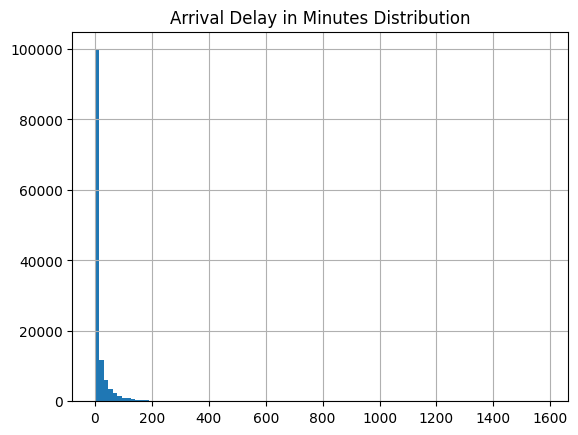

In [ ]:
df['Arrival Delay in Minutes'].hist(bins=100)
plt.title("Arrival Delay in Minutes Distribution")
plt.show()

**Arrival Delay Distribution Interpretation**

The histogram reveals a highly **right-skewed distribution** of arrival delays.  
- Most flights arrive on time or within a few minutes of schedule.  
- A small number of flights experience extreme delays, creating a long tail on the right.  
- This pattern suggests that while delays are generally rare, they can be severe when they occur.  
- The skewness justifies using the **median** rather than the mean for imputation.


In [ ]:
# Here we impute Arrival Delay in Minutes column with the median

median_delay = df['Arrival Delay in Minutes'].median()
df['Arrival Delay in Minutes'].fillna(median_delay, inplace=True)

/tmp/ipykernel_2373/4128011878.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Arrival Delay in Minutes'].fillna(median_delay, inplace=True)


In [ ]:
#Confirming if it is effected

df['Arrival Delay in Minutes'].isnull().sum()

np.int64(0)

# FEATURE ENGINEERING

Several predictors in the dataset are categorical and cannot be used directly by Scikit-learn.

These variables were encoded into numerical representations so that the Logistic Regression algorithm could process them effectively.

Examples of these variables include: `satisfaction`, `Customer Type`, `Type of Travel`, and `Travel Class` variables

In [ ]:
df['satisfaction'].value_counts()

,count
satisfaction,
satisfied,71087
dissatisfied,58793


The **satisfaction** column represents the target variable for prediction.  
- Out of 129,880 passengers, **71,087 (≈55%)** reported being *satisfied*, while **58,793 (≈45%)** were *dissatisfied*.  
- This indicates a **moderately balanced dataset**, meaning the model will not be heavily biased toward one class.  
- The slight majority of satisfied customers suggests overall positive experiences, but there’s still a significant portion of dissatisfied passengers — providing valuable insights for improvement.


In [ ]:
df['Customer Type'].value_counts()

,count
Customer Type,
Loyal Customer,106100
disloyal Customer,23780


In [ ]:
df['Type of Travel'].value_counts()

,count
Type of Travel,
Business travel,89693
Personal Travel,40187


In [ ]:
df['Class'].value_counts()

,count
Class,
Business,62160
Eco,58309
Eco Plus,9411


# ENCODE CATEGORICAL VARIABLES

In [ ]:
le = LabelEncoder()
for col in ['satisfaction', 'Customer Type', 'Type of Travel', 'Class']:
    df[col] = le.fit_transform(df[col])


Logistic Regression requires a binary target variable. Therefore, the satisfaction variable was encoded such that:

1 = Satisfied
0 = Dissatisfied

also Customer Type along with the other two categorical data was converted into numerical forms so that it could be interpreted by the model.

**Confirming if the Encoding Process worked**

In [ ]:
df['satisfaction'].value_counts()

,count
satisfaction,
1,71087
0,58793


In [ ]:
df['Customer Type'].value_counts()

,count
Customer Type,
0,106100
1,23780


In [ ]:
df['Type of Travel'].value_counts()

,count
Type of Travel,
0,89693
1,40187


In [ ]:
df['Class'].value_counts()

,count
Class,
0,62160
1,58309
2,9411


# SPLIT DATA FOR TRAINING AND TESTING

In [ ]:
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


The dataset was divided into training and testing subsets using an 80/20 split.

In [ ]:
X.head()

,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,0,65,1,1,265,0,0,0,2,2,...,2,3,3,0,3,5,3,2,0,0.0
1,0,47,1,0,2464,0,0,0,3,0,...,2,3,4,4,4,2,3,2,310,305.0
2,0,15,1,1,2138,0,0,0,3,2,...,2,2,3,3,4,4,4,2,0,0.0
3,0,60,1,1,623,0,0,0,3,3,...,3,1,1,0,1,4,1,3,0,0.0
4,0,70,1,1,354,0,0,0,3,4,...,4,2,2,0,2,4,2,5,0,0.0


In [ ]:
y.head()

,satisfaction
0,1
1,1
2,1
3,1
4,1


# BUILD AND FIT LOGISTIC REGRESSION MODEL

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

A Logistic Regression model was trained to estimate the probability that a passenger is satisfied.

Unlike Linear Regression, Logistic Regression is specifically designed for binary classification problems and produces probabilities between 0 and 1.

# MODEL EVALUATION

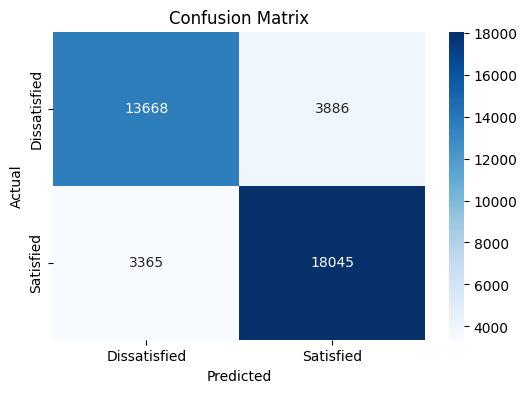

In [ ]:
# Generate predictions
y_pred = model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot with seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


The confusion matrix shows that the model correctly identified 19,895 satisfied passengers and 16,846 dissatisfied passengers

However, 3,630 dissatisfied passengers were incorrectly classified as satisfied while 3,605 satisfied passengers were incorrectly classified as dissatisfied

Overall, the model demonstrates strong classification performance with relatively balanced error rates across both classes.

In [ ]:
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)


Accuracy: 0.8139051432091161
Precision: 0.8228078974966941
Recall: 0.842830453059318


The model achieved an Accuracy of 81.4%, Precision of 82.3% and a Recall rate of 84.3%.

Precision indicates that when the model predicts a passenger is satisfied, it is correct approximately 82% of the time.

Recall indicates that the model successfully identifies approximately 84% of all truly satisfied passengers.

Together, these metrics suggest that the model performs well in identifying satisfied customers while maintaining a relatively low false-positive rate.

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)


In [ ]:
coefficients

,Feature,Coefficient
10,Inflight entertainment,0.610292
5,Seat comfort,0.303425
12,Ease of Online booking,0.288175
13,On-board service,0.278618
16,Checkin service,0.227864
14,Leg room service,0.175048
18,Online boarding,0.085787
11,Online support,0.041933
15,Baggage handling,0.039973
8,Gate location,0.026125


##**Key Positive Drivers**

`Inflight Entertainment` (+0.610)

`Inflight entertainment` is the strongest positive predictor of satisfaction in the model.

Passengers who give higher ratings for inflight entertainment are substantially more likely to be satisfied compared with passengers who provide lower ratings.

`Seat Comfort` (+0.303)

Seat comfort is the second strongest positive driver of satisfaction, suggesting that passenger comfort plays a critical role in the overall travel experience.

`Ease of Online Booking` (+0.288)

A smoother booking experience increases the likelihood of customer satisfaction. This highlights the importance of digital convenience throughout the customer journey.

`On-board Service` (+0.279)

Passengers who perceive better service from airline staff are more likely to report satisfaction.

`Check-in Service` (+0.228)

Efficient and pleasant check-in experiences contribute positively to overall customer satisfaction.

##**Key Negative Drivers**
`Customer Type` (-2.520)

Customer Type has the strongest negative coefficient in the model.

This suggests that one customer segment is substantially less likely to be satisfied than the reference group.

`Class` (-0.793)

Travel class significantly influences satisfaction outcomes. The negative coefficient indicates that some classes may be associated with lower satisfaction levels relative to the reference category.

`Type of Travel` (-0.616)

Passenger travel purpose appears to influence satisfaction, indicating that business and personal travelers may have different expectations and experiences.

`Departure/Arrival Time Convenience` (-0.281)

Passengers who perceive flight schedules as inconvenient are less likely to report satisfaction.

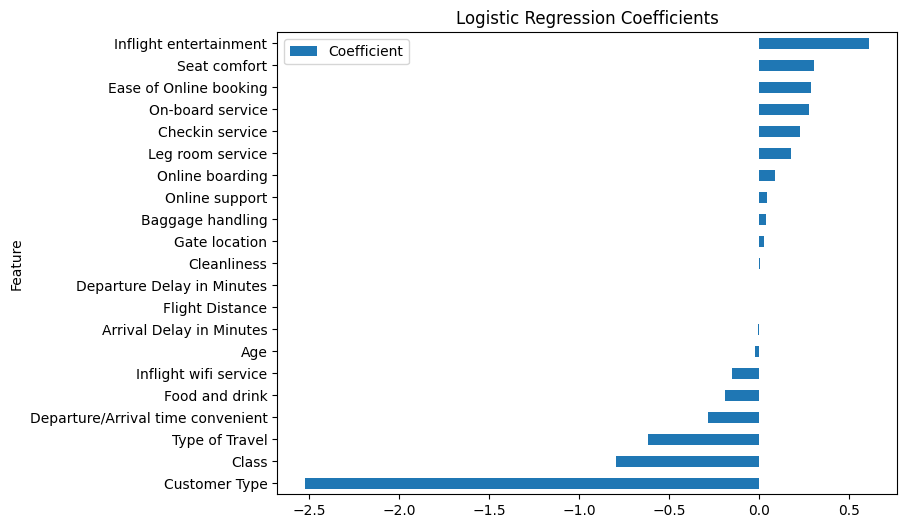

In [ ]:
# Grapical representation of these coefficient
coefficients.sort_values('Coefficient').plot(
    x='Feature',
    y='Coefficient',
    kind='barh',
    figsize=(8,6)
)
plt.title("Logistic Regression Coefficients")
plt.show()

# BUSINESS INSIGHTS

The analysis suggests that customer satisfaction is driven primarily by service quality and travel experience rather than operational metrics.

Features such as inflight entertainment, seat comfort, online booking, onboard service, and check-in service demonstrate stronger effects than delay-related variables.

Interestingly, arrival and departure delays have relatively small coefficients, suggesting that passengers may place greater emphasis on the overall travel experience than minor scheduling disruptions.

# BUSINESS RECOMMENDATIONS

Based on the Logistic Regression model, the airline should prioritize investments in customer experience initiatives that are most strongly associated with satisfaction.

**Recommendation 1:** Improve Inflight Entertainment

Inflight entertainment produced the largest positive coefficient in the model (+0.610), making it the strongest driver of satisfaction. Expanding entertainment options, improving content quality, and ensuring system reliability could increase passenger satisfaction levels.

Recommendation 2: Enhance Seat Comfort

Seat comfort emerged as the second strongest positive factor. Investments in seating quality, legroom optimization, and cabin ergonomics could improve the passenger experience.

**Recommendation 3:** Streamline Digital Services

Ease of online booking and online boarding both contributed positively to satisfaction. The airline should continue investing in user-friendly digital platforms and self-service technologies.

**Recommendation 4:** Strengthen Customer Service Training

On-board service and check-in service were among the strongest positive predictors. Training frontline employees to provide consistent, high-quality service could yield measurable improvements in customer satisfaction.

**Recommendation 5:** Target At-Risk Customer Segments

Customer Type and Type of Travel showed strong negative effects. Further investigation should identify which passenger groups are less satisfied so that targeted retention and loyalty strategies can be developed.